# 🔍 Exploración API ENTSOG —> Red Gasista España

## ¿Qué es ENTSOG?
ENTSOG = European Network of Transmission System Operators for Gas

Es la plataforma oficial europea donde se publican en tiempo real
todos los flujos físicos de gas natural entre países.

**Datos clave:**
- Gratuita y sin registro
- Actualización diaria
- Cubre todos los gasoductos de Europa
- Incluye coordenadas geográficas de cada punto

## ¿Por qué nos interesa?
Con estos datos podemos saber exactamente cuánto gas
entra a España, de dónde viene, y por qué gasoducto.

In [47]:
# ================================================
# Importamos las librerías que vamos a usar
# ================================================
# requests → para hacer llamadas a APIs web
# pandas   → para organizar datos en tablas
# json     → para leer el formato de respuesta
# ================================================

import requests
import pandas as pd
import json

from datetime import date, timedelta

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print("✓ Librerías cargadas")
print(f"  pandas versión: {pd.__version__}")
print(f"  requests versión: {requests.__version__}")

✓ Librerías cargadas
  pandas versión: 3.0.1
  requests versión: 2.32.5


## Paso 1: Entender la API de ENTSOG

La URL base de la API es:
`https://transparency.entsog.eu/api/v1/`

Los endpoints principales que usaremos:
- `/operationalData` → flujos físicos de gas por punto y día
- `/interconnections` → lista de todos los puntos de interconexión
- `/operators` → operadores de red por país

Primero exploramos los puntos de interconexión de España
para entender la estructura de los datos.

In [48]:
# ================================================
# LLAMADA 1 — Puntos de interconexión de España
# ================================================
# Preguntamos a ENTSOG: ¿qué puntos de entrada
# y salida de gas existen en España?
# ================================================

url = "https://transparency.entsog.eu/api/v1/interconnections"

params = {
    "countryKey": "ES",    # ES = España
    "limit": 100
}

print("Conectando con ENTSOG...")
respuesta = requests.get(url, params=params, timeout=30) #Timeout para evitar que la conexión se quede colgada

# Verificamos que la conexión fue exitosa
# 200 = OK, cualquier otro número = error
# 400 no encontrado y 500 error del servidor
print(f"Código de respuesta: {respuesta.status_code}")

if respuesta.status_code == 200:
    print("✓ Conexión exitosa")
else:
    print("✗ Error en la conexión")

Conectando con ENTSOG...
Código de respuesta: 200
✓ Conexión exitosa


In [49]:
# ================================================
# ¿Cómo están organizados los datos?
# ================================================
# La API devuelve JSON — un formato de texto
# organizado en claves y valores, como un
# diccionario de Python
# ================================================

# Convertimos la respuesta a diccionario Python
datos = respuesta.json()

# Vemos las claves principales del diccionario
print("Claves principales del JSON:")
print(list(datos.keys()))


Claves principales del JSON:
['meta', 'interconnections']


In [50]:
# ================================================
# Exploramos los datos en detalle
# ================================================
# Aprendimos que el JSON tiene dos claves:
# 'meta'             → información sobre la consulta
# 'interconnections' → los datos reales que queremos
# ================================================

# Miramos qué hay en meta
print("=== META (info de la consulta) ===")
print(json.dumps(datos['meta'], indent=2))

# Cuántos puntos encontró
print(f"\n=== TOTAL PUNTOS DE INTERCONEXIÓN ESPAÑA: {len(datos['interconnections'])} ===")

# Primer punto — su estructura completa
print("\n=== PRIMER PUNTO DE INTERCONEXIÓN ===")
print(json.dumps(datos['interconnections'][0], indent=2))

=== META (info de la consulta) ===
{
  "limit": 100,
  "offset": 0,
  "fields": [
    "pointKey",
    "pointLabel",
    "isSingleOperator",
    "pointTpMapX",
    "pointTpMapY",
    "fromSystemLabel",
    "fromInfrastructureTypeLabel",
    "fromCountryKey",
    "fromCountryLabel",
    "fromBzKey",
    "fromBzLabel",
    "fromBzLabelLong",
    "fromOperatorKey",
    "fromOperatorLabel",
    "fromOperatorLongLabel",
    "fromPointKey",
    "fromPointLabel",
    "fromIsCAM",
    "fromIsCMP",
    "fromBookingPlatformKey",
    "fromBookingPlatformLabel",
    "fromBookingPlatformURL",
    "toIsCAM",
    "toIsCMP",
    "toBookingPlatformKey",
    "toBookingPlatformLabel",
    "toBookingPlatformURL",
    "fromTsoItemIdentifier",
    "fromTsoPointLabel",
    "fromDirectionKey",
    "fromHasData",
    "toSystemLabel",
    "toInfrastructureTypeLabel",
    "toCountryKey",
    "toCountryLabel",
    "toBzKey",
    "toBzLabel",
    "toBzLabelLong",
    "toOperatorKey",
    "toOperatorLabel",
    "toO

## Paso 3: Convertir los datos a una tabla legible

Tenemos 13 puntos de interconexión de España.
Vamos a convertirlos a un DataFrame de pandas —
que es básicamente una tabla como Excel pero en Python.

Campos más importantes que encontramos:
- `pointLabel`      → nombre del punto de interconexión
- `pointTpMapX/Y`   → coordenadas geográficas (longitud/latitud)
- `fromCountryLabel`→ país de origen del gas
- `toCountryLabel`  → país destino del gas

In [51]:
# ================================================
# Convertimos el JSON a DataFrame (tabla)
# ================================================
# pd.DataFrame() toma una lista de diccionarios
# y la convierte en una tabla con filas y columnas
# ================================================

df = pd.DataFrame(datos['interconnections'])

print(f"Dimensiones de la tabla: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\nColumnas disponibles:")
print(df.columns.tolist())

Dimensiones de la tabla: 100 filas x 55 columnas

Columnas disponibles:
['pointKey', 'pointLabel', 'isSingleOperator', 'pointTpMapX', 'pointTpMapY', 'fromSystemLabel', 'fromInfrastructureTypeLabel', 'fromCountryKey', 'fromCountryLabel', 'fromBzKey', 'fromBzLabel', 'fromBzLabelLong', 'fromOperatorKey', 'fromOperatorLabel', 'fromOperatorLongLabel', 'fromPointKey', 'fromPointLabel', 'fromIsCAM', 'fromIsCMP', 'fromBookingPlatformKey', 'fromBookingPlatformLabel', 'fromBookingPlatformURL', 'toIsCAM', 'toIsCMP', 'toBookingPlatformKey', 'toBookingPlatformLabel', 'toBookingPlatformURL', 'fromTsoItemIdentifier', 'fromTsoPointLabel', 'fromDirectionKey', 'fromHasData', 'toSystemLabel', 'toInfrastructureTypeLabel', 'toCountryKey', 'toCountryLabel', 'toBzKey', 'toBzLabel', 'toBzLabelLong', 'toOperatorKey', 'toOperatorLabel', 'toOperatorLongLabel', 'toPointKey', 'toPointLabel', 'toDirectionKey', 'toHasData', 'toTsoItemIdentifier', 'toTsoPointLabel', 'validFrom', 'validto', 'lastUpdateDateTime', 'isIn

In [52]:
# ================================================
# Seleccionamos solo las columnas que nos interesan
# ================================================

columnas_clave = [
    'pointLabel',        # nombre del punto
    'fromCountryLabel',  # país origen
    'toCountryLabel',    # país destino  
    'pointTpMapX',       # longitud (coordenada X)
    'pointTpMapY',       # latitud  (coordenada Y)
    'fromInfrastructureTypeLabel'  # tipo: gasoducto, GNL, etc
]

df_limpio = df[columnas_clave].copy()

print("=== PUNTOS DE INTERCONEXIÓN ESPAÑA ===\n")
print(df_limpio.to_string(index=False))

=== PUNTOS DE INTERCONEXIÓN ESPAÑA ===

                                             pointLabel fromCountryLabel toCountryLabel  pointTpMapX  pointTpMapY fromInfrastructureTypeLabel
                                      Distribution (PT)         Portugal       Portugal      -128.19       -69.50                Transmission
                                Distribution (FR North)           France         France       -47.48        -6.23                Transmission
                                      Distribution (IT)            Italy          Italy       -20.00       -59.49                Transmission
                   Aggregated Distribution - H-gas (PL)           Poland         Poland        25.49        -4.87                Distribution
                   Aggregated Distribution - H-gas (PL)           Poland         Poland        25.49        -4.87                Transmission
                                        Greater Belfast   United Kingdom United Kingdom      -113.25        

In [53]:
# ================================================
# LLAMADA 2 — Flujos operacionales de España
# ================================================
# Este endpoint sí tiene los gasoductos reales
# que entran y salen de España
# ================================================



# Pedimos los últimos 7 días
hoy = date.today()
hace_7_dias = hoy - timedelta(days=7)

url2 = "https://transparency.entsog.eu/api/v1/operationalData"

params2 = {
    "forceDownload": "true",
    "countryKey":    "ES",
    "from":          hace_7_dias.isoformat(),  # formato: 2026-03-18
    "to":            hoy.isoformat(),           # formato: 2026-03-25
    "indicator":     "Physical Flow",
    "periodType":    "day",
    "limit":         500
}

print(f"Pidiendo datos del {hace_7_dias} al {hoy}...")
respuesta2 = requests.get(url2, params=params2, timeout=60)
print(f"Código respuesta: {respuesta2.status_code}")

Pidiendo datos del 2026-03-18 al 2026-03-25...
Código respuesta: 200


In [54]:
# ================================================
# Exploramos el JSON de operationalData paso a paso
# ================================================

datos2 = respuesta2.json()

# PASO 1 — ¿Qué claves tiene el JSON raíz?
print("=== PASO 1: Claves del JSON ===")
print(list(datos2.keys()))

# PASO 2 — ¿Qué dice el meta?
print("\n=== PASO 2: Meta (resumen de la consulta) ===")
print(f"Total registros disponibles : {datos2['meta'].get('total', 'N/A')}")
print(f"Registros traídos           : {datos2['meta'].get('count', 'N/A')}")

# PASO 3 — ¿Cuántas filas tenemos?
print(f"\n=== PASO 3: Filas en operationalData ===")
print(f"Número de filas: {len(datos2['operationalData'])}")

# PASO 4 — Primera fila completa
print("\n=== PASO 4: Primera fila (un día, un gasoducto) ===")
print(json.dumps(datos2['operationalData'][0], indent=2))


=== PASO 1: Claves del JSON ===
['meta', 'operationalData']

=== PASO 2: Meta (resumen de la consulta) ===
Total registros disponibles : 500
Registros traídos           : 500

=== PASO 3: Filas en operationalData ===
Número de filas: 500

=== PASO 4: Primera fila (un día, un gasoducto) ===
{
  "id": "1Physical FlowdayBG-TSO-0001ITP-00292entrykWh/d2026-01-012027-01-01_NA0",
  "dataSet": 1,
  "indicator": "Physical Flow",
  "periodType": "day",
  "periodFrom": "2026-03-18T06:00:00+01:00",
  "periodTo": "2026-03-19T06:00:00+01:00",
  "operatorKey": "BG-TSO-0001",
  "tsoEicCode": "21X-BG-A-A0A0A-C",
  "operatorLabel": "Bulgartransgaz",
  "pointKey": "ITP-00292",
  "pointLabel": "GMS Ihtiman",
  "tsoItemIdentifier": "21Z000000000308R",
  "directionKey": "entry",
  "unit": "kWh/d",
  "itemRemarks": "GMS Ihtiman is not relevant point as of 29 March 2018. GMS Ihtiman has been virtualized. Its capacity is commercially marketed at Transfer point NGTN <-> GTNTT since January 2017.",
  "generalRem

In [55]:
# ================================================
# Convertimos a DataFrame y filtramos España
# ================================================
# Un DataFrame es como una hoja de Excel en Python
# Filas = registros, Columnas = campos del JSON
# ================================================

# PASO 1 — Toda la lista a tabla
df2 = pd.DataFrame(datos2['operationalData'])

print(f"Tabla completa: {df2.shape[0]} filas x {df2.shape[1]} columnas")

# PASO 2 — ¿Qué operadores/países tenemos?
print("\n=== Operadores únicos en los datos ===")
display(df2['operatorLabel'].unique())

# PASO 3 — Cuántos registros tienen value vacío
vacios = df2[df2['value'] == ''].shape[0]
print(f"\nRegistros con value vacío: {vacios}")
print(f"Registros con value real:  {df2.shape[0] - vacios}")

Tabla completa: 500 filas x 32 columnas

=== Operadores únicos en los datos ===


<StringArray>
[      'Bulgartransgaz',               'ONTRAS',               'Nowega',
     'Open Grid Europe',    'jordgas Transport',            'Energinet',
               'GRTgaz',           'GAZ-SYSTEM',                  'GTS',
         'terranets bw',     'GAZ-SYSTEM (ISO)',                  'GNI',
       'Fluxys Belgium',   'NaTran Deutschland',              'Elering',
     'National Gas TSO', 'Premier Transmission']
Length: 17, dtype: str


Registros con value vacío: 500
Registros con value real:  0


In [56]:
# ================================================
# LLAMADA 3 — Datos correctos de España
# ================================================
# Usamos el operatorKey de Enagás directamente
# y pedimos un período con datos confirmados
# ================================================

desde = date(2026, 2, 1)   # febrero — datos ya publicados
hasta = date(2026, 2, 28)

params3 = {
    "forceDownload": "true",
    "operatorKey":   "ES-TSO-0001",   # Enagás — operador España
    "from":          desde.isoformat(),
    "to":            hasta.isoformat(),
    "indicator":     "Physical Flow",
    "periodType":    "day",
    "limit":         1000
}

print(f"Pidiendo flujos de Enagás del {desde} al {hasta}...")
respuesta3 = requests.get(
    "https://transparency.entsog.eu/api/v1/operationalData",
    params=params3,
    timeout=60
)
print(f"Código respuesta: {respuesta3.status_code}")

# ================================================
# Diagnóstico — ¿Qué devolvió la API exactamente?
# ================================================
# Antes de asumir la estructura, siempre
# inspeccionamos la respuesta cruda primero
# ================================================

# Primero las claves que tiene este JSON
print("Claves del JSON:")
print(list(datos3.keys()))

# El texto crudo de los primeros 500 caracteres
print("\nRespuesta cruda (primeros 500 caracteres):")
print(respuesta3.text[:500])


Pidiendo flujos de Enagás del 2026-02-01 al 2026-02-28...
Código respuesta: 404
Claves del JSON:
['message']

Respuesta cruda (primeros 500 caracteres):
{"message":"No result found"}


In [57]:
# ================================================
# Buscamos Enagás filtrando por nombre
# ================================================
# Traemos TODOS los operadores y filtramos
# los que contengan "ES" en su key o 
# "Spain" / "Enagas" en su nombre
# ================================================

# Traemos todos sin filtro de país
resp_todos = requests.get(
    "https://transparency.entsog.eu/api/v1/operators",
    params={"limit": 1000},
    timeout=30
)

todos = resp_todos.json()['operators']
print(f"Total operadores en Europa: {len(todos)}")

# Filtramos los que tienen "ES-" en el key
print("\n=== Operadores con código ES- (España) ===")
espana = [op for op in todos if str(op.get('operatorKey','')).startswith('ES-')]

for op in espana:
    print(f"  key: {op.get('operatorKey')} | nombre: {op.get('operatorLabel')}")

Total operadores en Europa: 541

=== Operadores con código ES- (España) ===
  key: ES-ETO-0001 | nombre: Enagás S.A.
  key: ES-ETO-0002 | nombre: EnaGás Renovable
  key: ES-LSO-0001 | nombre: Gascan
  key: ES-SSO-0001 | nombre: ESCAL UGS S.L.
  key: ES-SSO-0002 | nombre: GasNatural fenosa
  key: ES-SSO-0003 | nombre: Enagas (SSO)
  key: ES-TSO-0001 | nombre: Medgaz
  key: ES-TSO-0002 | nombre: Reganosa (LSO)
  key: ES-TSO-0003 | nombre: Saggas
  key: ES-TSO-0004 | nombre: ETN
  key: ES-TSO-0005 | nombre: BBG
  key: ES-TSO-0006 | nombre: Enagas
  key: ES-TSO-0007 | nombre: GNA
  key: ES-TSO-0008 | nombre: EMPL
  key: ES-TSO-0009 | nombre: Reganosa
  key: ES-TSO-0010 | nombre: Enagas (LSO)
  key: ES-H2O-0001 | nombre: EIH
  key: ES-TSO-0011 | nombre: Enagas SNAM
  key: ES-H2O-0002 | nombre: Repsol
  key: ES-H2O-0003 | nombre: CEPSA
  key: ES-H2O-0004 | nombre: Bay of Biscay H2
  key: ES-H2O-0005 | nombre: T-HYNET
  key: ES-H2O-0006 | nombre: C-HYNET
  key: ES-H2O-0007 | nombre: H2 ABONO


## Visualización — Operadores de gas en España

Antes de pedir flujos, visualizamos los operadores
que encontramos agrupados por tipo:

- TSO = Transmission System Operator (red troncal)
- SSO = Storage System Operator (almacenamiento)
- LSO = LNG System Operator (terminales GNL)
- ETO = Entity (otros)
- H2O = Hidrógeno (futuro)

Esto nos da una foto del ecosistema gasista español.

In [58]:
# ================================================
# Gráfico — Operadores de gas en España por tipo
# ================================================
# Usamos matplotlib para visualizar
# los operadores agrupados por categoría
# ================================================



# Creamos DataFrame con los operadores de España
df_espana = pd.DataFrame(espana)
print(f"Columnas disponibles: {df_espana.columns.tolist()}")
print(df_espana[['operatorKey', 'operatorLabel']].head())

Columnas disponibles: ['operatorLogoUrl', 'operatorKey', 'operatorLabel', 'operatorLabelLong', 'operatorTooltip', 'operatorCountryKey', 'operatorCountryLabel', 'operatorCountryFlag', 'operatorTypeLabel', 'operatorTypeLabelLong', 'participates', 'membershipLabel', 'tsoEicCode', 'tsoDisplayName', 'tsoShortName', 'tsoLongName', 'tsoStreet', 'tsoBuildingNumber', 'tsoPostOfficeBox', 'tsoZipCode', 'tsoCity', 'tsoContactName', 'tsoContactPhone', 'tsoContactEmail', 'tsoContactUrl', 'tsoContactRemarks', 'tsoGeneralWebsiteUrl', 'tsoGeneralWebsiteUrlRemarks', 'tsoTariffInformationUrl', 'tsoTariffInformationUrlRemarks', 'tsoTariffCalculatorUrl', 'tsoTariffCalculatorUrlRemarks', 'tsoCapacityInformationUrl', 'tsoCapacityInformationUrlRemarks', 'tsoGasQualityURL', 'tsoGasQualityURLRemarks', 'tsoAccessConditionsUrl', 'tsoAccessConditionsUrlRemarks', 'tsoContractDocumentsUrl', 'tsoContractDocumentsUrlRemarks', 'tsoMaintainanceUrl', 'tsoMaintainanceUrlRemarks', 'gasDayStartHour', 'gasDayStartHourRemarks

In [59]:
# ================================================
# Extraemos el TIPO de operador desde el código
# ================================================
# El código tiene el formato: ES-TIPO-XXXX
# ES-TSO-0001 → tipo = TSO
# ES-SSO-0001 → tipo = SSO
# Usamos .str.split('-') para separarlo
# ================================================

# Seleccionamos solo las columnas que necesitamos
df_plot = df_espana[['operatorKey', 'operatorLabel', 'operatorTypeLabel']].copy()

# Extraemos el tipo del código
# "ES-TSO-0006".split('-') → ['ES', 'TSO', '0006']
# [1] → 'TSO'
df_plot['tipo'] = df_plot['operatorKey'].str.split('-').str[1]

# Significado de cada tipo
significados = {
    'TSO': 'Red Troncal',
    'SSO': 'Almacenamiento',
    'LSO': 'Terminal GNL',
    'ETO': 'Entidad',
    'H2O': 'Hidrógeno'
}
df_plot['tipo_nombre'] = df_plot['tipo'].map(significados)

# Contamos cuántos operadores hay por tipo
conteo = df_plot.groupby(['tipo', 'tipo_nombre']).size().reset_index(name='cantidad')
conteo = conteo.sort_values('cantidad', ascending=True)

print(conteo)

  tipo     tipo_nombre  cantidad
2  LSO    Terminal GNL         1
0  ETO         Entidad         2
3  SSO  Almacenamiento         3
4  TSO     Red Troncal        12
1  H2O       Hidrógeno        18


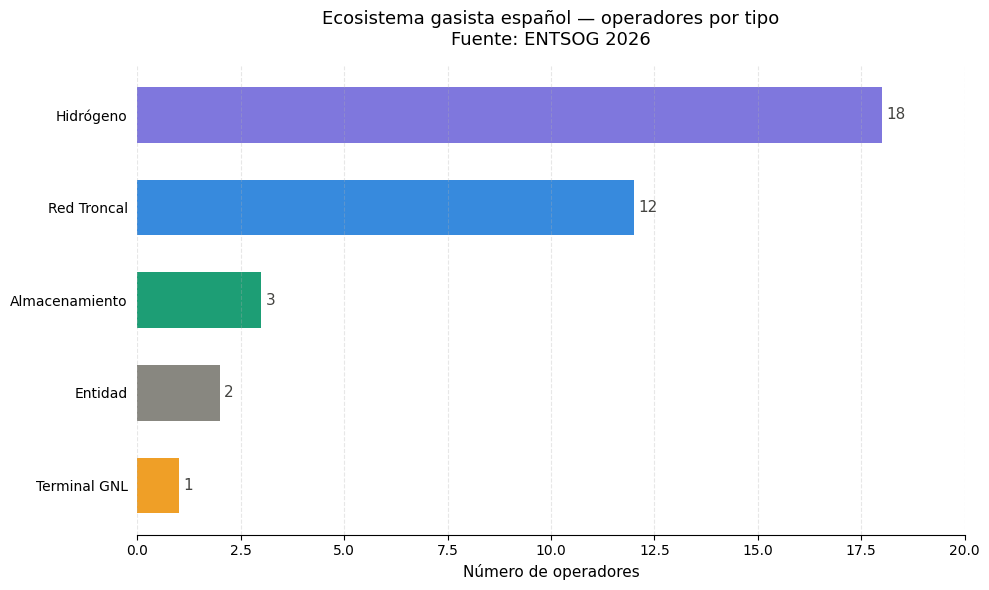


✓ Gráfico guardado en data/processed/operadores_espana.png


In [60]:
# ================================================
# Gráfico de barras horizontal — operadores España
# ================================================
# Horizontal porque los nombres son largos
# Colores por tipo de infraestructura
# ================================================

colores = {
    'TSO': '#378ADD',   # azul   — red troncal
    'SSO': '#1D9E75',   # verde  — almacenamiento
    'LSO': '#EF9F27',   # ámbar  — GNL
    'ETO': '#888780',   # gris   — entidades
    'H2O': '#7F77DD'    # púrpura — hidrógeno
}

fig, ax = plt.subplots(figsize=(10, 6))

barras = ax.barh(
    conteo['tipo_nombre'],
    conteo['cantidad'],
    color=[colores.get(t, '#888780') for t in conteo['tipo']],
    height=0.6,
    edgecolor='none'
)

# Añadir número al final de cada barra
for barra, valor in zip(barras, conteo['cantidad']):
    ax.text(
        barra.get_width() + 0.1,
        barra.get_y() + barra.get_height()/2,
        str(valor),
        va='center',
        fontsize=11,
        color='#444441'
    )

# Estilo limpio
ax.set_xlabel('Número de operadores', fontsize=11)
ax.set_title('Ecosistema gasista español — operadores por tipo\nFuente: ENTSOG 2026', 
             fontsize=13, pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(left=False)
ax.set_xlim(0, conteo['cantidad'].max() + 2)
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('../data/processed/operadores_espana.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Gráfico guardado en data/processed/operadores_espana.png")

In [61]:
# ================================================
# Preparamos los datos detallados por categoría
# ================================================
# Agregamos columna de tipo y filtramos
# solo los campos que necesitamos para graficar
# ================================================

df_plot['tipo'] = df_plot['operatorKey'].str.split('-').str[1]

# Separamos cada grupo
df_tso = df_plot[df_plot['tipo'] == 'TSO'].copy()
df_sso = df_plot[df_plot['tipo'] == 'SSO'].copy()
df_lso = df_plot[df_plot['tipo'] == 'LSO'].copy()
df_eto = df_plot[df_plot['tipo'] == 'ETO'].copy()
df_h2o = df_plot[df_plot['tipo'] == 'H2O'].copy()

print("=== RED TRONCAL (TSO) ===")
print(df_tso[['operatorKey','operatorLabel']].to_string(index=False))

print("\n=== ALMACENAMIENTO (SSO) ===")
print(df_sso[['operatorKey','operatorLabel']].to_string(index=False))

print("\n=== TERMINAL GNL (LSO) ===")
print(df_lso[['operatorKey','operatorLabel']].to_string(index=False))

print("\n=== ENTIDADES (ETO) ===")
print(df_eto[['operatorKey','operatorLabel']].to_string(index=False))

print("\n=== HIDRÓGENO (H2O) ===")
print(df_h2o[['operatorKey','operatorLabel']].to_string(index=False))

=== RED TRONCAL (TSO) ===
operatorKey        operatorLabel
ES-TSO-0001               Medgaz
ES-TSO-0002       Reganosa (LSO)
ES-TSO-0003               Saggas
ES-TSO-0004                  ETN
ES-TSO-0005                  BBG
ES-TSO-0006               Enagas
ES-TSO-0007                  GNA
ES-TSO-0008                 EMPL
ES-TSO-0009             Reganosa
ES-TSO-0010         Enagas (LSO)
ES-TSO-0011          Enagas SNAM
ES-TSO-0013  F INICIATIVAS I MAS

=== ALMACENAMIENTO (SSO) ===
operatorKey     operatorLabel
ES-SSO-0001    ESCAL UGS S.L.
ES-SSO-0002 GasNatural fenosa
ES-SSO-0003      Enagas (SSO)

=== TERMINAL GNL (LSO) ===
operatorKey operatorLabel
ES-LSO-0001        Gascan

=== ENTIDADES (ETO) ===
operatorKey    operatorLabel
ES-ETO-0001      Enagás S.A.
ES-ETO-0002 EnaGás Renovable

=== HIDRÓGENO (H2O) ===
operatorKey      operatorLabel
ES-H2O-0001                EIH
ES-H2O-0002             Repsol
ES-H2O-0003              CEPSA
ES-H2O-0004   Bay of Biscay H2
ES-H2O-0005            

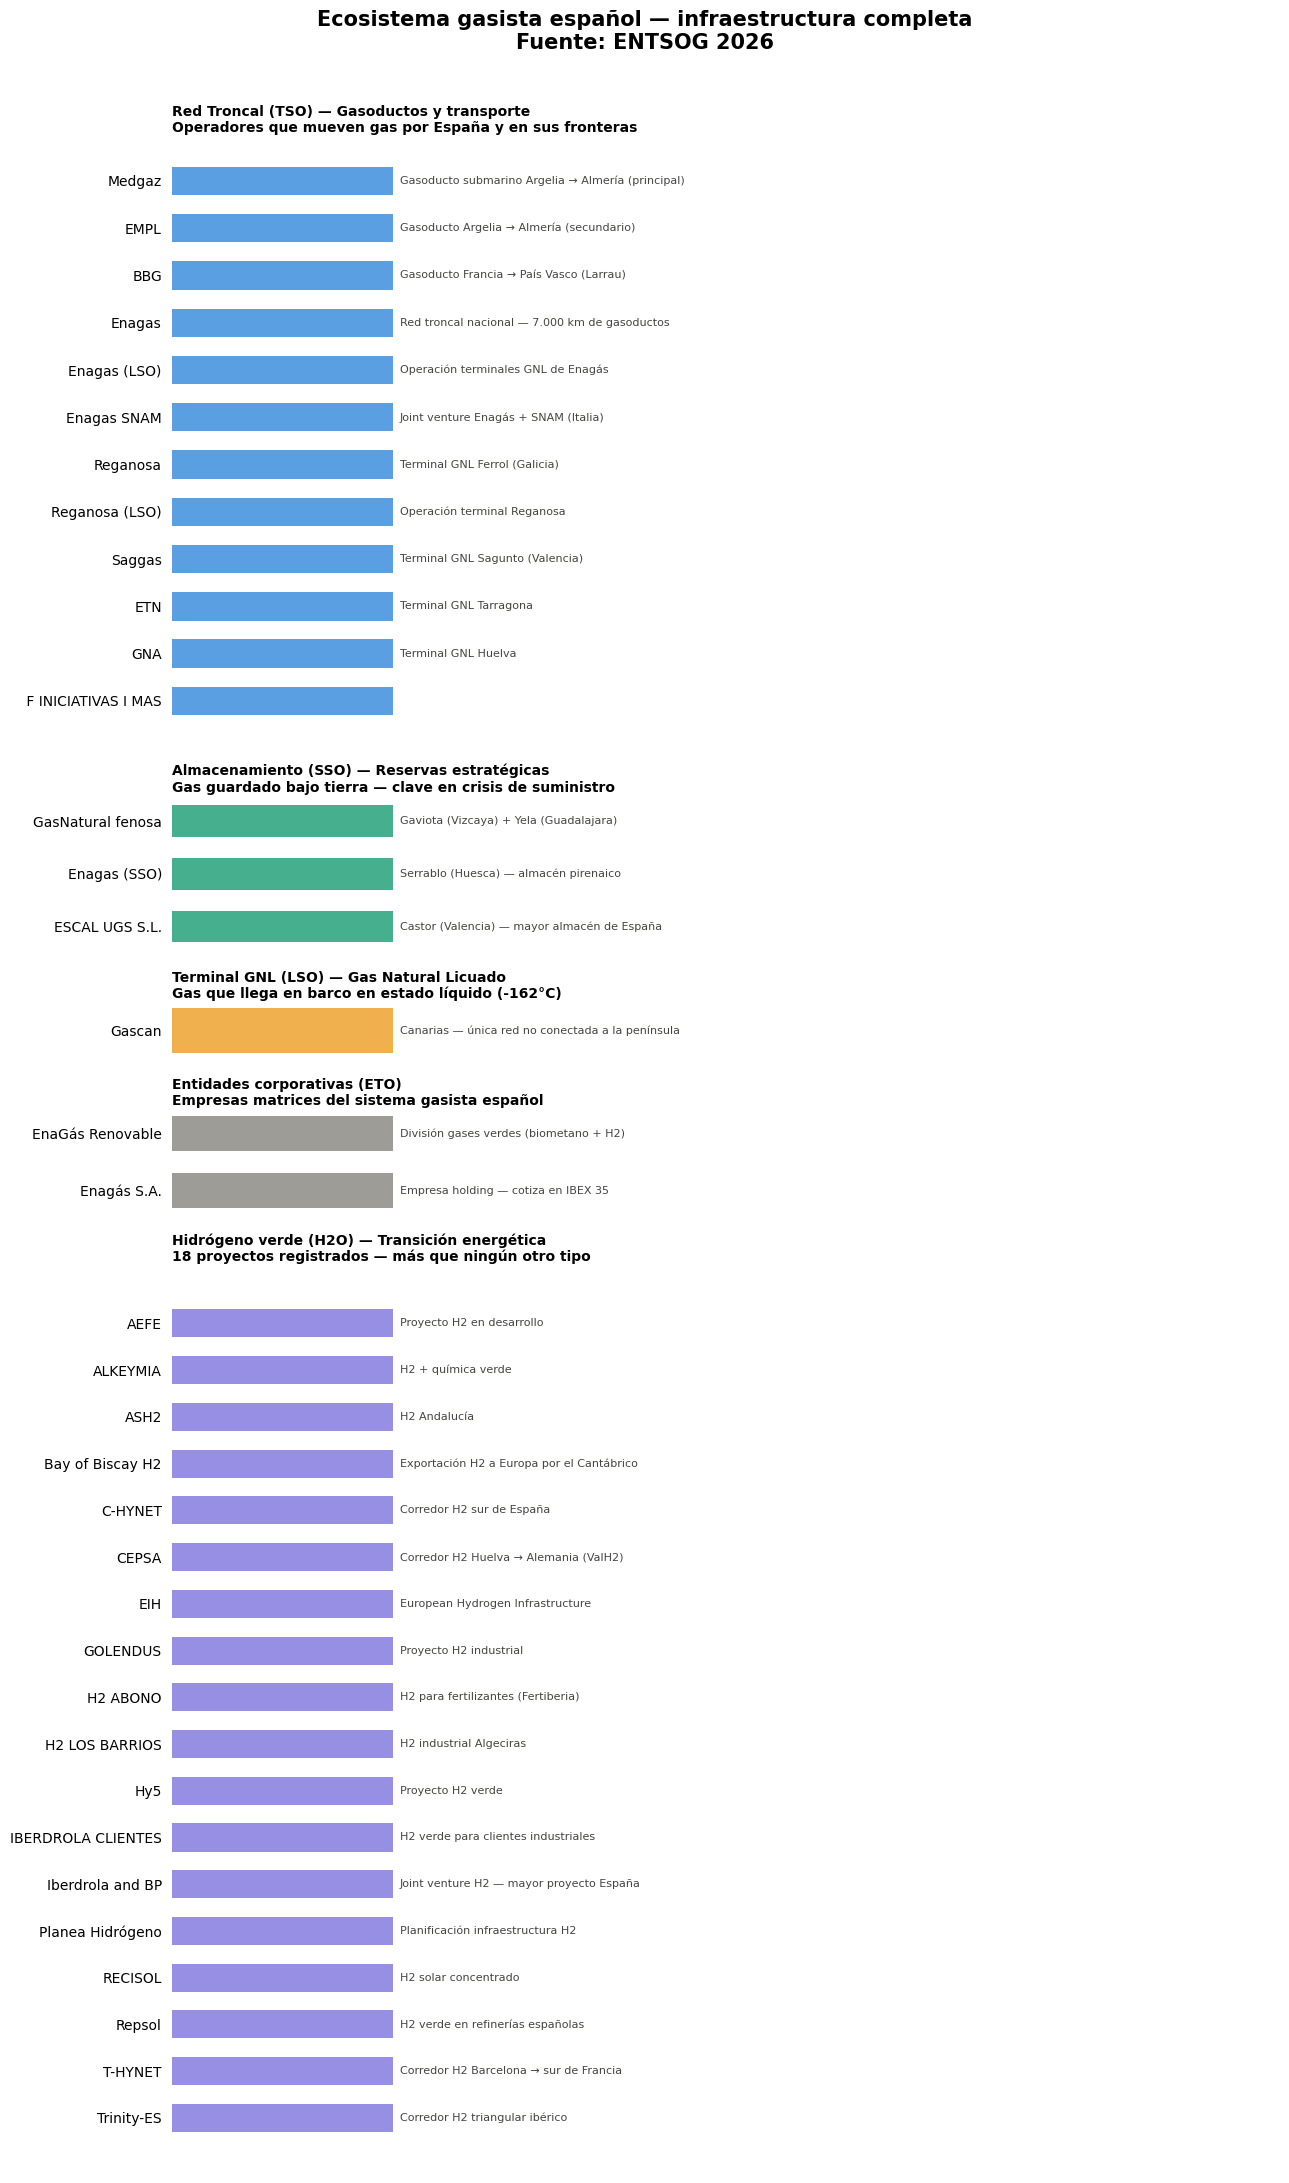

✓ Gráfico v2 guardado


In [64]:
# ================================================
# Figura completa — Ecosistema gasista España
# 5 subgráficos, uno por categoría
# ================================================

# ================================================
# Orden correcto por importancia
# ================================================

fig, axes = plt.subplots(
    5, 1,
    figsize=(13, 22),
    gridspec_kw={
        'height_ratios': [
            len(df_tso),   # 12 — más grande
            len(df_sso),   # 3
            len(df_lso),   # 1
            len(df_eto),   # 2
            len(df_h2o),   # 18 — más grande
        ]
    }
)

fig.suptitle(
    'Ecosistema gasista español — infraestructura completa\nFuente: ENTSOG 2026',
    fontsize=15, fontweight='bold', y=0.99
)

# ── Orden correcto por importancia ───────────────
df_tso_ord = df_tso.copy()
orden_tso = [
    'Medgaz', 'EMPL', 'BBG', 'Enagas', 'Enagas (LSO)',
    'Enagas SNAM', 'Reganosa', 'Reganosa (LSO)',
    'Saggas', 'ETN', 'GNA', 'F INICIATIVAS I MAS'
]
df_tso_ord['orden'] = df_tso_ord['operatorLabel'].map(
    {v: i for i, v in enumerate(orden_tso)}
).fillna(99)
df_tso_ord = df_tso_ord.sort_values('orden', ascending=False)

df_sso_ord = df_sso.sort_values('operatorLabel', ascending=True)
df_h2o_ord = df_h2o.sort_values('operatorLabel', ascending=False)

categorias2 = [
    {
        'df':       df_tso_ord,
        'titulo':   'Red Troncal (TSO) — Gasoductos y transporte',
        'subtitulo':'Operadores que mueven gas por España y en sus fronteras',
        'color':    '#378ADD',
        'notas': {
            'Medgaz':              'Gasoducto submarino Argelia → Almería (principal)',
            'EMPL':                'Gasoducto Argelia → Almería (secundario)',
            'BBG':                 'Gasoducto Francia → País Vasco (Larrau)',
            'Enagas':              'Red troncal nacional — 7.000 km de gasoductos',
            'Enagas (LSO)':        'Operación terminales GNL de Enagás',
            'Enagas SNAM':         'Joint venture Enagás + SNAM (Italia)',
            'Reganosa':            'Terminal GNL Ferrol (Galicia)',
            'Reganosa (LSO)':      'Operación terminal Reganosa',
            'Saggas':              'Terminal GNL Sagunto (Valencia)',
            'ETN':                 'Terminal GNL Tarragona',
            'GNA':                 'Terminal GNL Huelva',
            'F INICIATIVAS I MAS': 'Proyecto en desarrollo',
        }
    },
    {
        'df':       df_sso_ord,
        'titulo':   'Almacenamiento (SSO) — Reservas estratégicas',
        'subtitulo':'Gas guardado bajo tierra — clave en crisis de suministro',
        'color':    '#1D9E75',
        'notas': {
            'ESCAL UGS S.L.':    'Castor (Valencia) — mayor almacén de España',
            'Enagas (SSO)':      'Serrablo (Huesca) — almacén pirenaico',
            'GasNatural fenosa': 'Gaviota (Vizcaya) + Yela (Guadalajara)',
        }
    },
    {
        'df':       df_lso,
        'titulo':   'Terminal GNL (LSO) — Gas Natural Licuado',
        'subtitulo':'Gas que llega en barco en estado líquido (-162°C)',
        'color':    '#EF9F27',
        'notas': {
            'Gascan': 'Canarias — única red no conectada a la península',
        }
    },
    {
        'df':       df_eto,
        'titulo':   'Entidades corporativas (ETO)',
        'subtitulo':'Empresas matrices del sistema gasista español',
        'color':    '#888780',
        'notas': {
            'Enagás S.A.':       'Empresa holding — cotiza en IBEX 35',
            'EnaGás Renovable':  'División gases verdes (biometano + H2)',
        }
    },
    {
        'df':       df_h2o_ord,
        'titulo':   'Hidrógeno verde (H2O) — Transición energética',
        'subtitulo':'18 proyectos registrados — más que ningún otro tipo',
        'color':    '#7F77DD',
        'notas': {
            'EIH':               'European Hydrogen Infrastructure',
            'Repsol':            'H2 verde en refinerías españolas',
            'CEPSA':             'Corredor H2 Huelva → Alemania (ValH2)',
            'Bay of Biscay H2':  'Exportación H2 a Europa por el Cantábrico',
            'T-HYNET':           'Corredor H2 Barcelona → sur de Francia',
            'C-HYNET':           'Corredor H2 sur de España',
            'H2 ABONO':          'H2 para fertilizantes (Fertiberia)',
            'H2 LOS BARRIOS':    'H2 industrial Algeciras',
            'IBERDROLA CLIENTES':'H2 verde para clientes industriales',
            'GOLENDUS':          'Proyecto H2 industrial',
            'Planea Hidrógeno':  'Planificación infraestructura H2',
            'ALKEYMIA':          'H2 + química verde',
            'Hy5':               'Proyecto H2 verde',
            'Iberdrola and BP':  'Joint venture H2 — mayor proyecto España',
            'ASH2':              'H2 Andalucía',
            'RECISOL':           'H2 solar concentrado',
            'Trinity-ES':        'Corredor H2 triangular ibérico',
            'AEFE':              'Proyecto H2 en desarrollo',
        }
    },
]

# ── Dibujar cada subgráfico ───────────────────────
for ax, cat in zip(axes, categorias2):
    nombres = cat['df']['operatorLabel'].tolist()
    
    barras = ax.barh(
        nombres,
        [1] * len(nombres),
        color=cat['color'],
        alpha=0.82,
        height=0.6,
        edgecolor='none'
    )
    
    # Notas explicativas
    for i, nombre in enumerate(nombres):
        nota = cat['notas'].get(nombre, '')
        ax.text(
            1.03, i, nota,
            va='center', fontsize=8,
            color='#444441'
        )
    
    ax.set_title(
        f"{cat['titulo']}\n{cat['subtitulo']}",
        fontsize=10, fontweight='bold',
        loc='left', pad=5
    )
    
    ax.set_xlim(0, 5)
    ax.set_xticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(left=False)

plt.tight_layout(rect=[0, 0, 1, 0.98], h_pad=1.5)
plt.savefig(
    '../data/processed/ecosistema_gasista_v2.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("✓ Gráfico v2 guardado")

  